In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

train_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input,   # <-- InceptionV3's own preprocessing (was rescale=1./255)
    shear_range=0.2,                           # <-- matched to baseline (was 0.3)
    zoom_range=0.2,                            # <-- matched to baseline (was 0.3)
    horizontal_flip=True,
)
validation_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [ ]:
train = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_train',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

validation = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_val',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

test = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_test',
    target_size = (224, 224),
    batch_size = 32,
    shuffle = False,
    class_mode = 'categorical'
)

Found 10500 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


In [ ]:
InceptionV3 = tf.keras.applications.InceptionV3(
    include_top=False,
    weights = 'imagenet',
    input_shape=(224,224,3),
    )

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
InceptionV3.trainable = False

In [ ]:
model = tf.keras.models.Sequential([
  InceptionV3,
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dropout(0.8),
  tf.keras.layers.Dense(units=1024, activation='relu'),
  tf.keras.layers.Dense(units=512, activation='relu'),
  tf.keras.layers.Dense(units=3, activation='softmax'),
])

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    52,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,758,947 (285.18 MB)

 Trainable params: 52,956,163 (202.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
history = model.fit(
    x = train,
    validation_data = validation,
    epochs = 10
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 6452s 19s/step - accuracy: 0.8750 - loss: 1.0045 - val_accuracy: 0.9480 - val_loss: 0.1464
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 200s 607ms/step - accuracy: 0.9284 - loss: 0.1806 - val_accuracy: 0.9473 - val_loss: 0.1406
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 199s 603ms/step - accuracy: 0.9305 - loss: 0.1816 - val_accuracy: 0.9513 - val_loss: 0.1252
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 196s 594ms/step - accuracy: 0.9352 - loss: 0.1650 - val_accuracy: 0.9513 - val_loss: 0.1221
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 193s 587ms/step - accuracy: 0.9397 - loss: 0.1565 - val_accuracy: 0.9573 - val_loss: 0.1074
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 191s 582ms/step - accuracy: 0.9394 - loss: 0.1457 - val_accuracy: 0.9480 - val_loss: 0.1365
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 196s 594ms/step - accuracy: 0.9490 - loss: 0.1368 - val_accuracy: 0.9573 - val_loss: 0.1209
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 196s 594ms/step - accuracy: 0.9495 - 

In [ ]:
# Evaluate the loss and accuracy
loss, accuracy = model.evaluate(test)

# Print the accuracy
print("Accuracy: " + str(accuracy))
# Print the loss
print("Loss: " + str(loss))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2204s 24s/step - accuracy: 0.9670 - loss: 0.0871
Accuracy: 0.9670000076293945
Loss: 0.08709224313497543


In [ ]:
test.class_indices

{'Lung_Adenocarcinoma': 0,
 'Lung_Benign_Tissue': 1,
 'Lung_Squamos_Cell_Carcinoma': 2}

In [ ]:
import numpy as np
from sklearn import metrics

predictions = model.predict(test)
predicted_classes = np.argmax(predictions, axis = 1)
true_classes = test.classes
class_labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
report = metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 251ms/step
                              precision    recall  f1-score   support

         Lung_Adenocarcinoma       0.94      0.97      0.95      1000
          Lung_Benign_Tissue       1.00      1.00      1.00      1000
Lung_Squamous_Cell_Carcinoma       0.97      0.94      0.95      1000

                    accuracy                           0.97      3000
                   macro avg       0.97      0.97      0.97      3000
                weighted avg       0.97      0.97      0.97      3000



<Axes: >

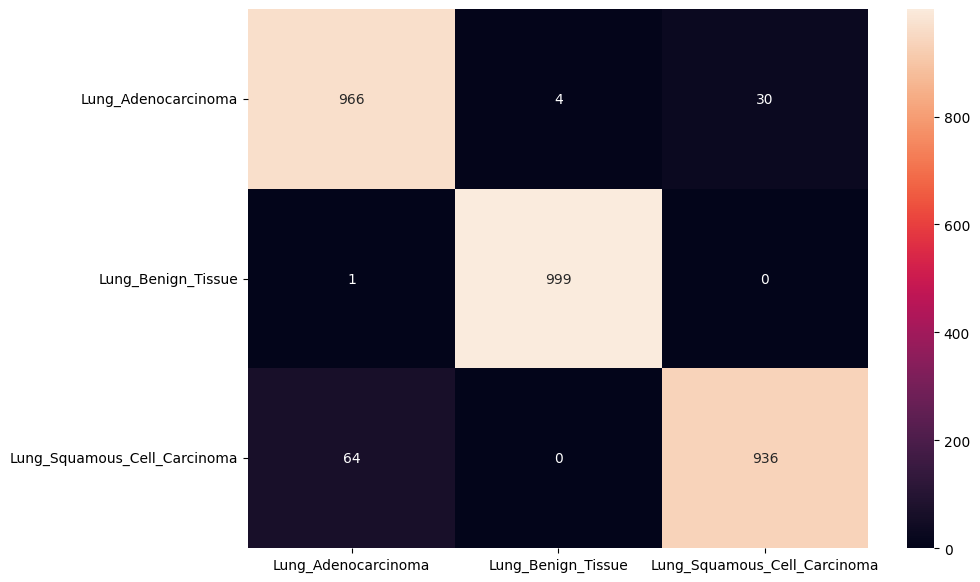

In [ ]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

# Label order MUST match test.class_indices: Adenocarcinoma=0, Benign=1, Squamous=2
labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
cm = metrics.confusion_matrix(true_classes, predicted_classes)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='d')


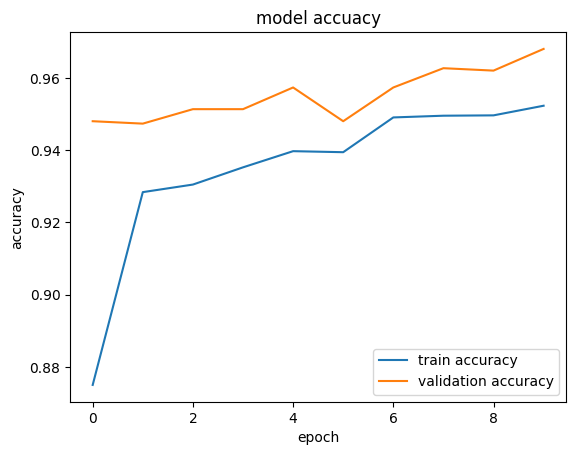

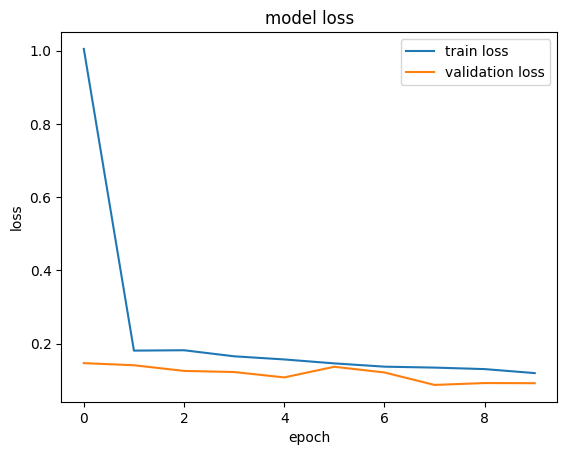

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("model accuacy")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'validation loss'], loc='upper right')
plt.show()